# Bike Counters — Visualizations (Tailored to `bike-trimmed.csv`)

This notebook is **customized** for the CSV **`bike-trimmed.csv`** which is the product of the execution of `bike-merge-with-limits.ipynb` and contains the columns:
- `colonnina` (station name)
- `data` (date)
- `totale` (daily total count of bikes)
- `VEL2024` (context field, not used here)

We create several time‑series charts using only these columns.
> Prerequisite: matplotlib installed

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
%matplotlib inline

CSV_PATH = Path('../data/bike-trimmed.csv') # change path if needed

# Load csv
df = pd.read_csv(CSV_PATH, parse_dates=['data'])
df = df.rename(columns={'data': 'timestamp', 'colonnina': 'station', 'totale': 'count'})
df = df.dropna(subset=['timestamp', 'station', 'count']).copy()
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df = df.dropna(subset=['count']).sort_values('timestamp').copy()

display(df.head(10))
print(f"Rows: {len(df):,} | Stations: {df['station'].nunique()} | Time span: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")

,station,timestamp,count,VEL2024
0,Ercolani,2018-12-31,19.0,50
5107,Sabotino,2018-12-31,11.0,50
1,Ercolani,2019-01-01,464.0,50
5108,Sabotino,2019-01-01,553.0,50
2,Ercolani,2019-01-02,816.0,50
5109,Sabotino,2019-01-02,868.0,50
3,Ercolani,2019-01-03,987.0,50
5110,Sabotino,2019-01-03,985.0,50
5111,Sabotino,2019-01-04,1063.0,50
4,Ercolani,2019-01-04,1037.0,50


Rows: 10,718 | Stations: 15 | Time span: 2018-12-31 → 2025-07-01


## Helper functions

Short utilities to aggregate and plot the data.

In [18]:
def resample_mean(df, freq):
    """Group by station and resample on timestamp using mean of 'count'."""
    g = (df.set_index('timestamp')
           .groupby('station')['count']
           .resample(freq)
           .mean()
           .rename('avg')
           .reset_index())
    return g

def plot_multiline(pivot_df, title, xlabel='Time', ylabel='Average Bikes'):
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in pivot_df.columns:
        ax.plot(pivot_df.index, pivot_df[col], label=col)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(loc='best', ncol=2)
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    plt.show()

def aggregate_half_year(df):
    """Aggregate to H1/H2 (semiannual) means per station."""
    tmp = df.copy()
    tmp['year'] = tmp['timestamp'].dt.year
    tmp['half'] = np.where(tmp['timestamp'].dt.month <= 6, 1, 2)
    agg = (tmp.groupby(['station','year','half'])['count']
              .mean()
              .rename('avg')
              .reset_index())
    # Representative period end for plotting (end of H1/H2)
    agg['period_end'] = pd.to_datetime(agg['year'].astype(str)) + pd.to_timedelta(agg['half']*6, unit='M') - pd.Timedelta(days=1)
    return agg

def make_index100_from_first(df_agg, value_col='avg'):
    """Within each station, normalize so the first available period == 100."""
    out = []
    for st, g in df_agg.groupby('station'):
        g = g.sort_values(g.columns[g.columns.str.contains('timestamp|period_end|date|time', case=False, regex=True)][0]).copy()
        base = g[value_col].iloc[0] if len(g) else np.nan
        g['index100'] = (g[value_col] / base) * 100.0 if base and not np.isnan(base) else np.nan
        out.append(g)
    return pd.concat(out, ignore_index=True) if out else df_agg.copy()

## Annual averages — all stations

**What this shows:** the **mean daily counts aggregated by year** for **each station**. This reveals overall trends and differences in magnitude across stations.

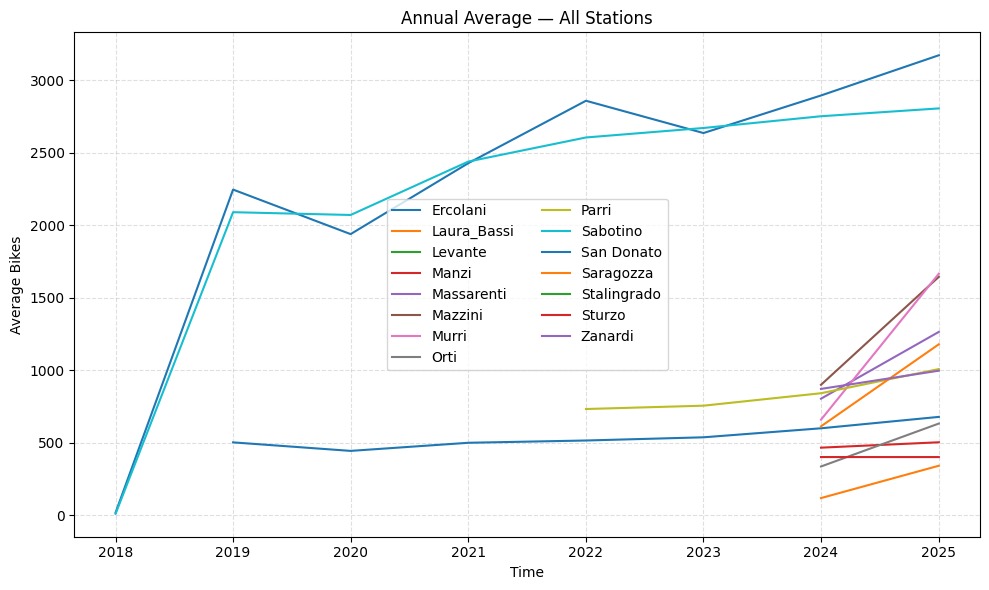

In [29]:
annual = resample_mean(df, 'YS')
piv = (annual.pivot(index='timestamp', columns='station', values='avg')
             .sort_index())
plot_multiline(piv, title='Annual Average — All Stations')

## Focus on the 3 stations present since 2019: *Ercolani*, *Sabotino*, *San Donato*

Below we compare these three long‑running stations at multiple time scales.

In [20]:
targets = ['Ercolani','Sabotino','San Donato']
df3 = df[df['station'].isin(targets)].copy()
missing = [t for t in targets if t not in df3['station'].unique()]
if missing:
    print("Warning: missing stations:", missing)
df3.head(3)

,station,timestamp,count,VEL2024
0,Ercolani,2018-12-31,19.0,50
5107,Sabotino,2018-12-31,11.0,50
1,Ercolani,2019-01-01,464.0,50


### Annual (3 stations)

**Why:** a high‑level comparison of year‑to‑year averages for the three stations.

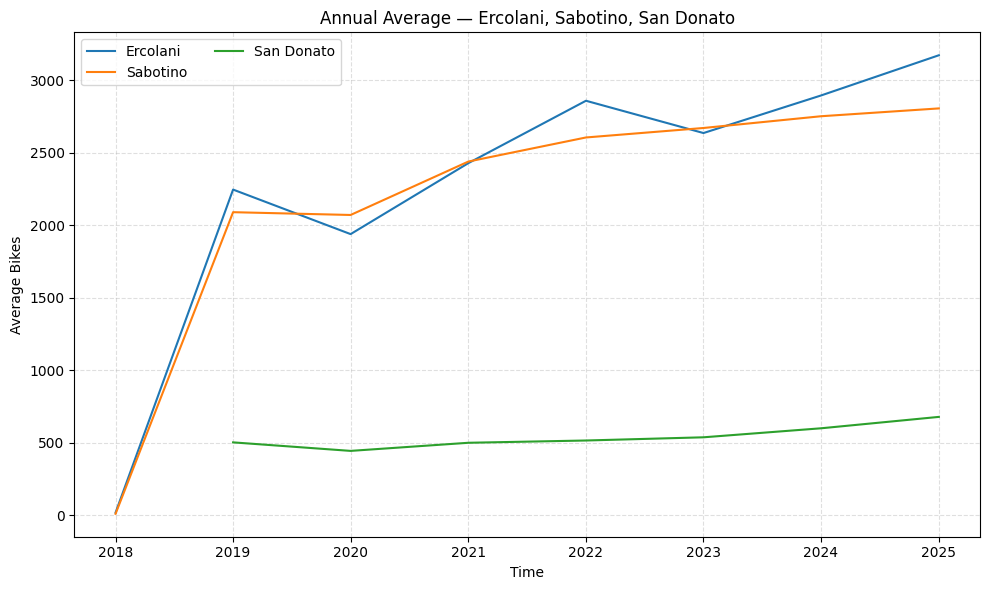

In [28]:
annual3 = resample_mean(df3, 'YS')
piv = (annual3.pivot(index='timestamp', columns='station', values='avg')
                 .sort_index())
plot_multiline(piv, title='Annual Average — Ercolani, Sabotino, San Donato')

### Quarterly (3 stations)

**Why:** quarterly smoothing balances noise and responsiveness, useful to spot seasonal patterns and medium‑term changes.

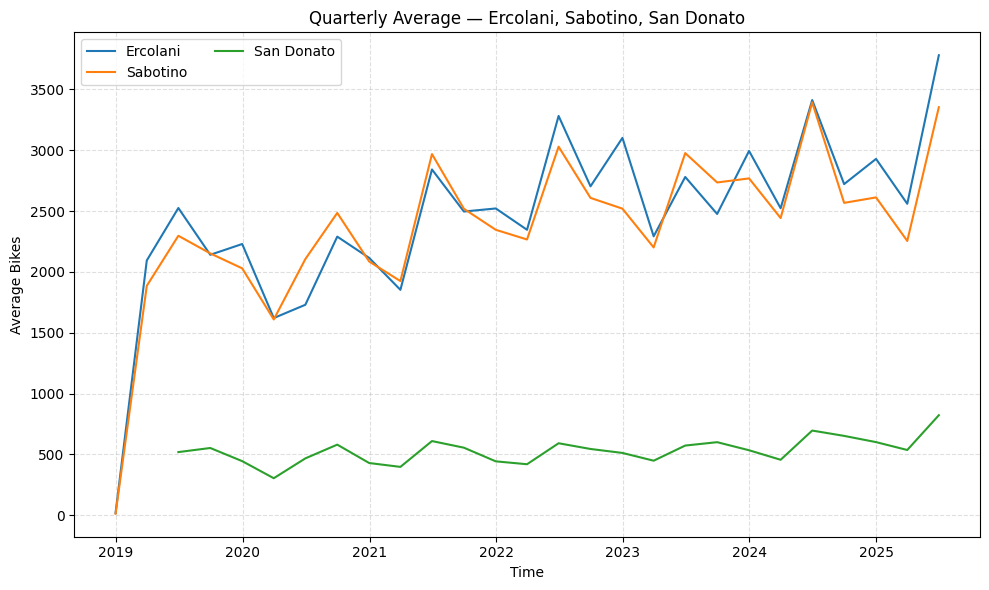

In [ ]:
quarterly3 = resample_mean(df3, 'QS')
piv = (quarterly3.pivot(index='timestamp', columns='station', values='avg')
                  .sort_index())
plot_multiline(piv, title='Quarterly Average — Ercolani, Sabotino, San Donato')

### Monthly (3 stations)

**Why:** monthly averages offer finer granularity to highlight short‑term shifts and seasonality.

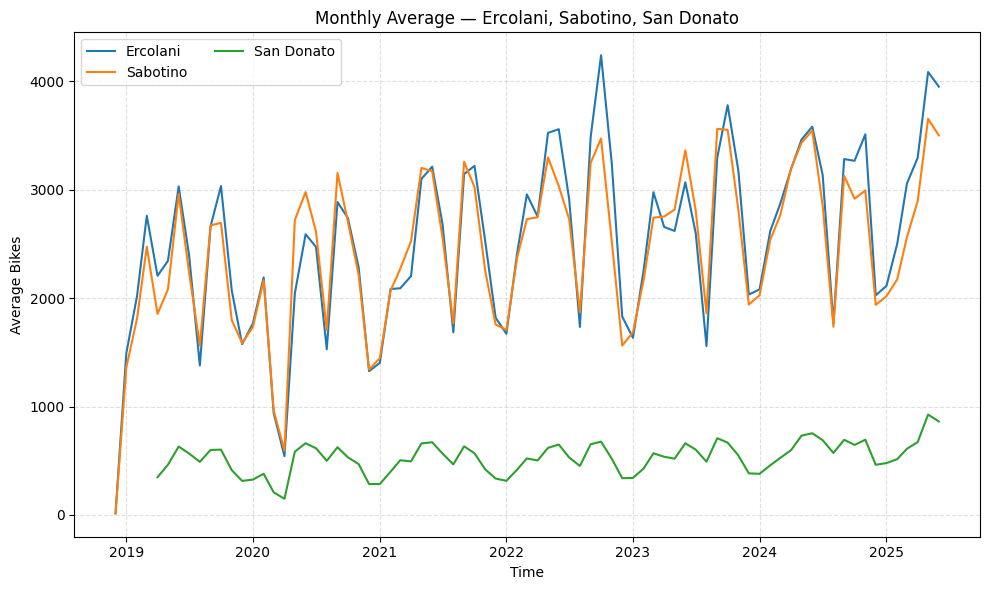

In [30]:
monthly3 = resample_mean(df3, 'MS')
piv = (monthly3.pivot(index='timestamp', columns='station', values='avg')
                .sort_index())
plot_multiline(piv, title='Monthly Average — Ercolani, Sabotino, San Donato')

## Index 100 — growth vs base

**What this shows:** the **relative growth** of the three station averaged over time, normalized so the **first available period = 100**. This focuses on change rather than absolute volumes.

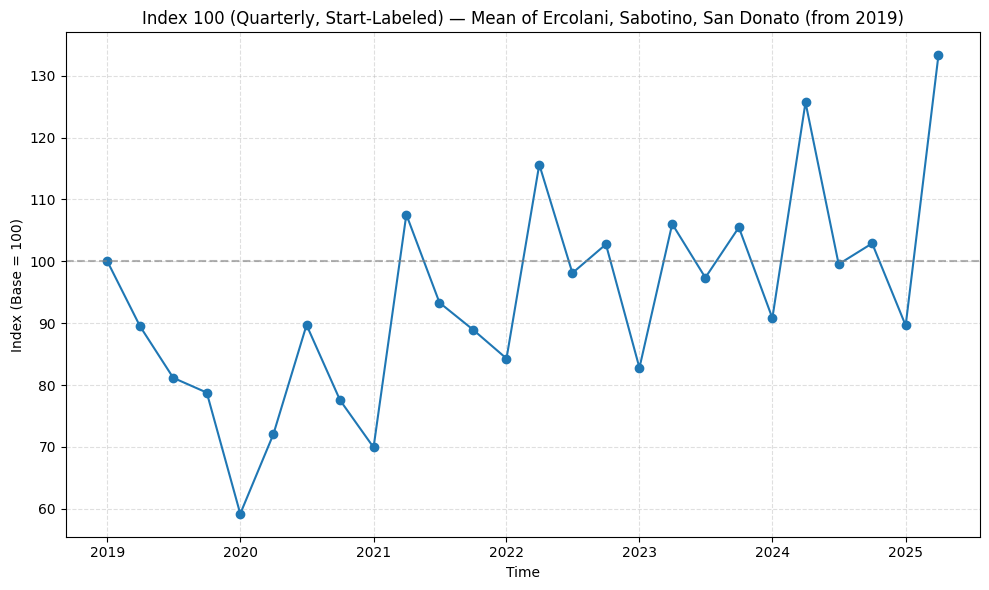

In [35]:
quarterly3 = resample_mean(df3, 'QS')

# Average across the three stations per quarter
avg_quarterly = (
    quarterly3.groupby('timestamp')['avg']
              .mean()
              .sort_index()
)

# filter 2019 onwards
avg_quarterly = avg_quarterly[avg_quarterly.index >= pd.Timestamp('2019-01-01')]

# Normalize so the first available quarter (2019 Q1) = 100
base = avg_quarterly.iloc[0]
idx_series = (avg_quarterly / base) * 100.0

# Plot a single Index 100 line
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(idx_series.index, idx_series.values, marker='o')

ax.axhline(100, linestyle='--', color='gray', alpha=0.6)
ax.set_title('Index 100 (Quarterly, Start-Labeled) — Mean of Ercolani, Sabotino, San Donato (from 2019)')
ax.set_xlabel('Time')
ax.set_ylabel('Index (Base = 100)')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

## Other visualization ideas

- **Day-of-week pattern**: highlight commute vs weekend differences.
- **Rolling mean (30/90 days)**: smooth out short‑term volatility to emphasize trends.
- **Share of total**: each station’s proportion of total city counts over time.

### Example: Day‑of‑week pattern (3 stations)

**Why:** helps understand weekly rhythms; useful for planning and anomaly detection.

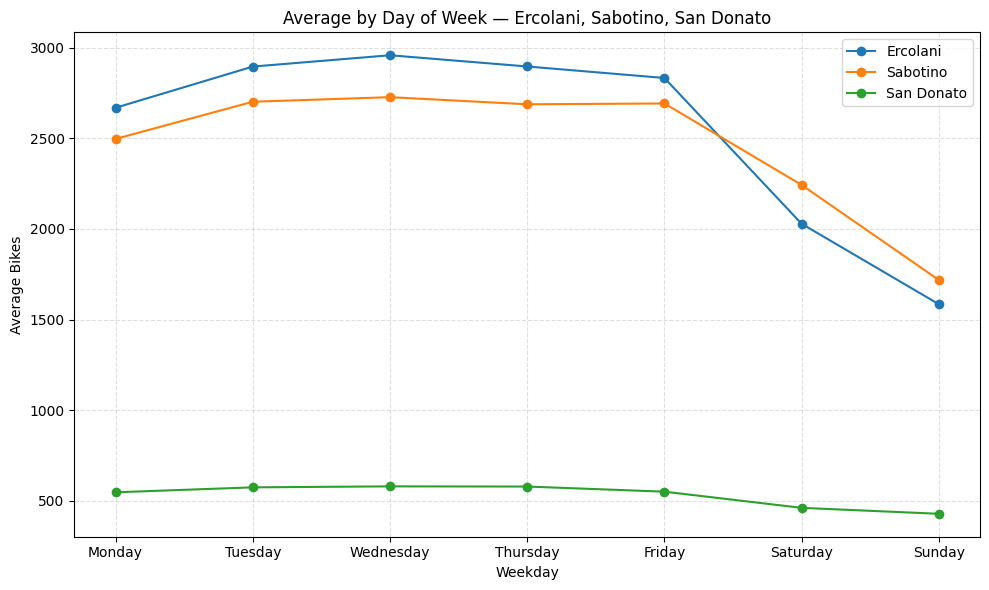

In [25]:
tmp = df3.copy()
tmp['weekday'] = tmp['timestamp'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

agg = (tmp.groupby(['station','weekday'])['count']
         .mean()
         .rename('avg')
         .reset_index())

piv = agg.pivot(index='weekday', columns='station', values='avg').reindex(order)

fig, ax = plt.subplots(figsize=(10, 6))
for col in piv.columns:
    ax.plot(piv.index, piv[col], marker='o', label=col)
ax.set_title('Average by Day of Week — Ercolani, Sabotino, San Donato')
ax.set_xlabel('Weekday')
ax.set_ylabel('Average Bikes')
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

## Semiannual (H1/H2) — 3 stations Average (single line)

**Why:** semiannual averages (H1/H2) give a concise overview of medium‑term change and help compare patterns across years with reduced noise. Average between the 3 station provides a more concise data too

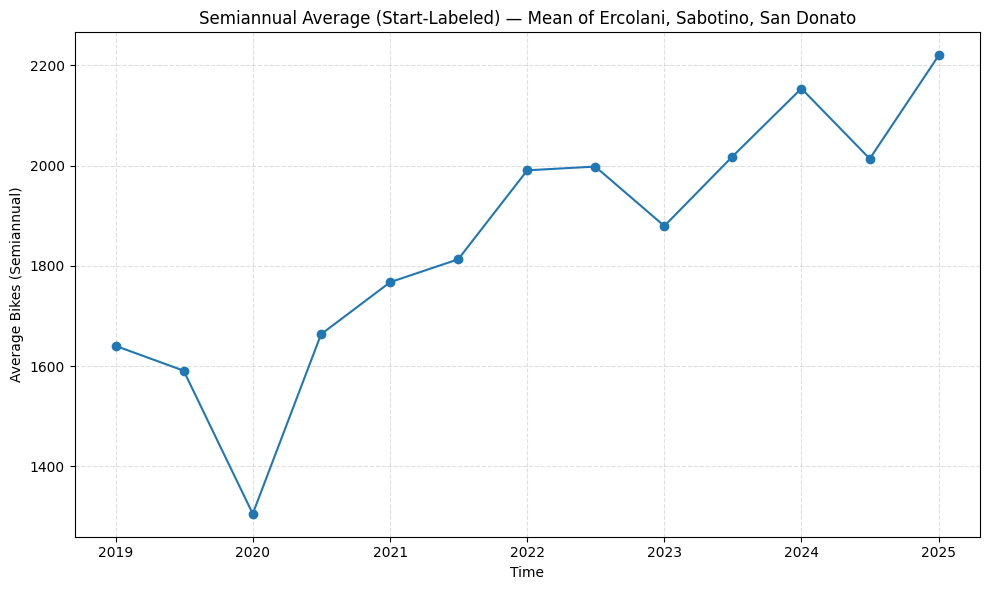

In [36]:
tmp = df3.copy()
tmp['year']  = tmp['timestamp'].dt.year
tmp['half']  = np.where(tmp['timestamp'].dt.month <= 6, 1, 2)   # 1=H1 (Jan–Jun), 2=H2 (Jul–Dec)

half = (
    tmp.groupby(['station', 'year', 'half'])['count']
       .mean()
       .rename('avg')
       .reset_index()
)

start_month = np.where(half['half'] == 1, 1, 7)
half['period_start'] = pd.to_datetime(
    half['year'].astype(str) + '-' + pd.Series(start_month, index=half.index).astype(str) + '-01',
    format='%Y-%m-%d'
)

# Filter 2019 onward
half = half[half['year'] >= 2019].copy()

# Average across the three stations for each semiannual period
avg3 = (
    half.groupby('period_start')['avg']
        .mean()
        .sort_index()
)

# Plot a single line representing the mean of the three stations
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(avg3.index, avg3.values, marker='o')

ax.set_title('Semiannual Average (Start-Labeled) — Mean of Ercolani, Sabotino, San Donato')
ax.set_xlabel('Time')
ax.set_ylabel('Average Bikes (Semiannual)')
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()
